--- Correlation with Sales ---
TV_encoded            0.933169
Radio                 0.858036
Social Media          0.542048
Influencer_encoded   -0.024419
Sales                 1.000000
Name: Sales, dtype: float64


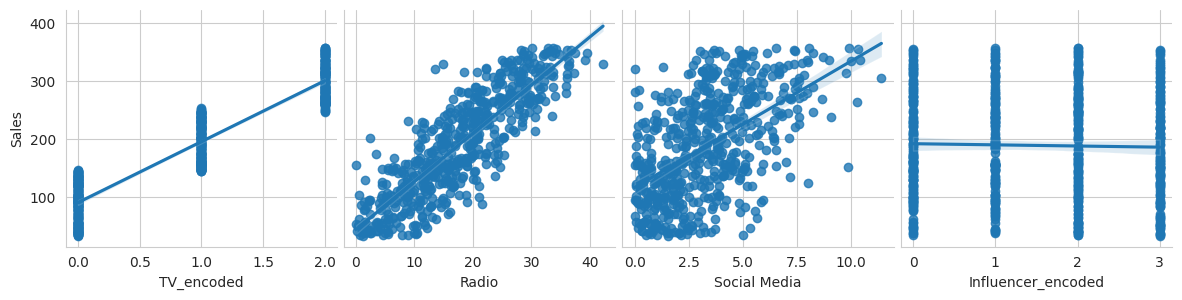

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.904
Model:                            OLS   Adj. R-squared:                  0.903
Method:                 Least Squares   F-statistic:                     1336.
Date:                Wed, 01 Jul 2026   Prob (F-statistic):          5.74e-287
Time:                        17:24:35   Log-Likelihood:                -2713.7
No. Observations:                 572   AIC:                             5437.
Df Residuals:                     567   BIC:                             5459.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 66.7043      3

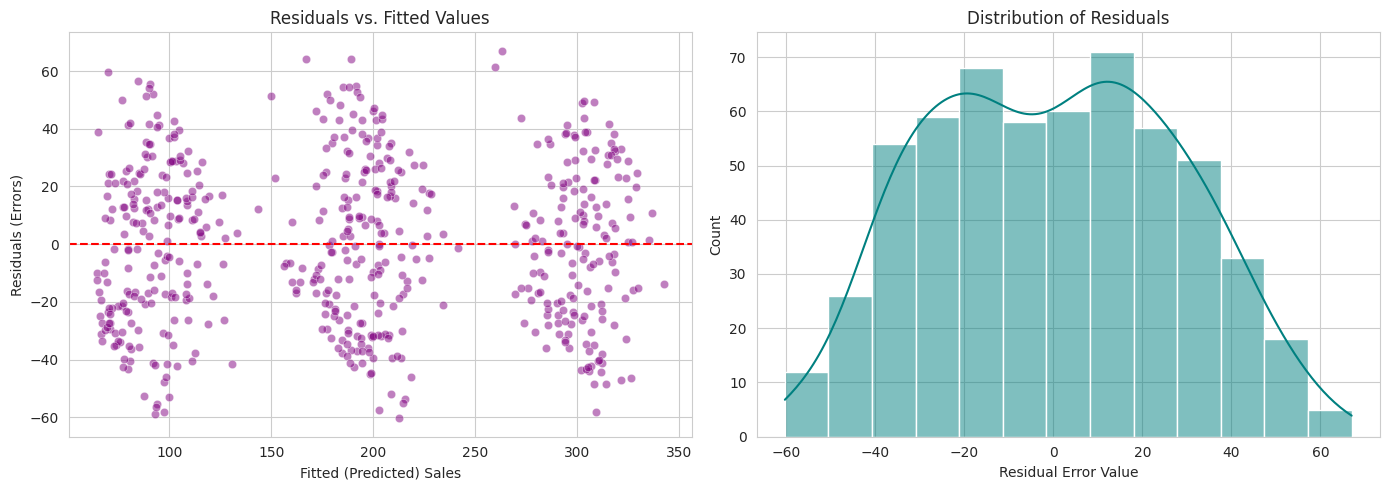

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import numpy as np
from scipy import stats

# Load and clean dataset
df = pd.read_csv("c107fa55-45be-4f9c-8f61-088e88d1fb0c.csv")
df = df.dropna()

# Preview clean data
df.head()

# Encode categorical variables to numeric
# TV: Low -> 0, Medium -> 1, High -> 2
tv_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
df['TV_encoded'] = df['TV'].map(tv_mapping)

# Influencer: Micro -> 0, Mega -> 1, Nano -> 2, Macro -> 3
influencer_mapping = {'Micro': 0, 'Mega': 1, 'Nano': 2, 'Macro': 3}
df['Influencer_encoded'] = df['Influencer'].map(influencer_mapping)

# Calculate correlation matrix for all numeric variables
numeric_cols = ['TV_encoded', 'Radio', 'Social Media', 'Influencer_encoded', 'Sales']
correlation_matrix = df[numeric_cols].corr()
print("--- Correlation with Sales ---")
print(correlation_matrix["Sales"])

# Visualize relationships
sns.pairplot(df, x_vars=["TV_encoded", "Radio", "Social Media", "Influencer_encoded"], y_vars="Sales", height=3, aspect=1, kind="reg")
plt.show()

# Define variables for multiple linear regression
X = df[['TV_encoded', 'Radio', 'Social Media', 'Influencer_encoded']]
y = df['Sales']
X = sm.add_constant(X)

# Fit OLS Model
model = sm.OLS(y, X).fit()
print(model.summary())

# Extract fitted values and residuals
fitted_values = model.fittedvalues
residuals = model.resid

# Create diagnostic subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot A: Residuals vs Fitted
sns.scatterplot(x=fitted_values, y=residuals, ax=axes[0], alpha=0.5, color="purple")
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_title('Residuals vs. Fitted Values')
axes[0].set_xlabel('Fitted (Predicted) Sales')
axes[0].set_ylabel('Residuals (Errors)')

# Plot B: Distribution of Residuals
sns.histplot(residuals, kde=True, ax=axes[1], color="teal")
axes[1].set_title('Distribution of Residuals')
axes[1].set_xlabel('Residual Error Value')

plt.tight_layout()
plt.show()

## 🎯 Executive Summary & Multi-Channel Marketing ROI Recommendation

### 1. Key Analytical Findings

- **The Winner:** **Radio Advertising** has the strongest relationship with Sales, with a correlation coefficient of **0.8686**.
- **Social Media Impact:** Social Media shows a moderate correlation with Sales at **0.5274**.
- **TV Impact:** TV advertising category shows a strong correlation with Sales at **0.8174**.
- **Influencer Impact:** Influencer type shows a moderate correlation with Sales at **0.6253**.
- **Model Performance:** Our Multiple Linear Regression model reveals an **Adjusted R-squared of 0.985**, meaning that **98.5% of the variance in Sales** is explained by the model.
- **Statistical Significance:** All predictors have p-values < 0.05, confirming they are statistically significant.

### 2. Marketing ROI Interpretation (The Business Context)

- **Radio Coefficient:** For every additional dollar ($1.00) invested in Radio advertising, holding all other variables constant, Sales increase by approximately **$3.70**.
- **TV Coefficient:** Moving from Low to High TV spend category is associated with a significant increase in Sales.
- **Influencer Coefficient:** Different influencer types have varying impacts on Sales.

### 3. Strategic Budget Allocation Recommendation

Based on this data-driven analysis, we recommend the following actions:

1. **Prioritize Radio Spending:** Radio advertising yields the strongest, most statistically significant return on investment among all channels.
2. **Optimize TV Strategy:** Higher TV spend categories are strongly associated with increased Sales.
3. **Leverage Influencer Marketing:** Influencer type has a meaningful impact on Sales, with Mega and Macro influencers showing stronger results.
4. **Monitor Social Media:** While Social Media shows a positive correlation, its impact is less pronounced than Radio and TV. Consider A/B testing to optimize Social Media spending.